In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import Pool, CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import optuna
from optuna.samplers import TPESampler
import warnings
import shap
warnings.filterwarnings("ignore")

C:\Users\prana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




**person_age**: Applicant’s age in years.

**person_income**: Annual income of the applicant in USD.

**person_home_ownership**: Status of homeownership (e.g., Rent, Own, Mortgage).

**person_emp_length**: Length of employment in years.

**loan_intent**: Purpose of the loan (e.g., Education, Medical, Personal).

**loan_grade**: Risk grade assigned to the loan, assessing the applicant’s creditworthiness.

**loan_amnt**: Total loan amount requested by the applicant.

**loan_int_rate**: Interest rate associated with the loan.

**loan_percent_income**: Percentage of the applicant’s income allocated towards loan repayment.

**cb_person_default_on_file**: Indicates if the applicant has a history of default ('Y' for yes, 'N' for no).

**cb_person_cred_hist_length**: Length of the applicant’s credit history in years.

**loan_status**: The approval status of the loan (approved or not approved).

In [6]:
train = pd.read_csv("playground-series-s4e10/train.csv", index_col="id")
test = pd.read_csv("playground-series-s4e10/test.csv", index_col="id")

print("Train shape: "+ str(train.shape))
print("Test shape: " + str(test.shape))

Train shape: (58645, 12)
Test shape: (39098, 11)


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58645 non-null  int64  
 1   person_income               58645 non-null  int64  
 2   person_home_ownership       58645 non-null  object 
 3   person_emp_length           58645 non-null  float64
 4   loan_intent                 58645 non-null  object 
 5   loan_grade                  58645 non-null  object 
 6   loan_amnt                   58645 non-null  int64  
 7   loan_int_rate               58645 non-null  float64
 8   loan_percent_income         58645 non-null  float64
 9   cb_person_default_on_file   58645 non-null  object 
 10  cb_person_cred_hist_length  58645 non-null  int64  
 11  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 5.8+ MB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39098 entries, 58645 to 97742
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  39098 non-null  int64  
 1   person_income               39098 non-null  int64  
 2   person_home_ownership       39098 non-null  object 
 3   person_emp_length           39098 non-null  float64
 4   loan_intent                 39098 non-null  object 
 5   loan_grade                  39098 non-null  object 
 6   loan_amnt                   39098 non-null  int64  
 7   loan_int_rate               39098 non-null  float64
 8   loan_percent_income         39098 non-null  float64
 9   cb_person_default_on_file   39098 non-null  object 
 10  cb_person_cred_hist_length  39098 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 3.6+ MB


Train Test Feature distribution comparison

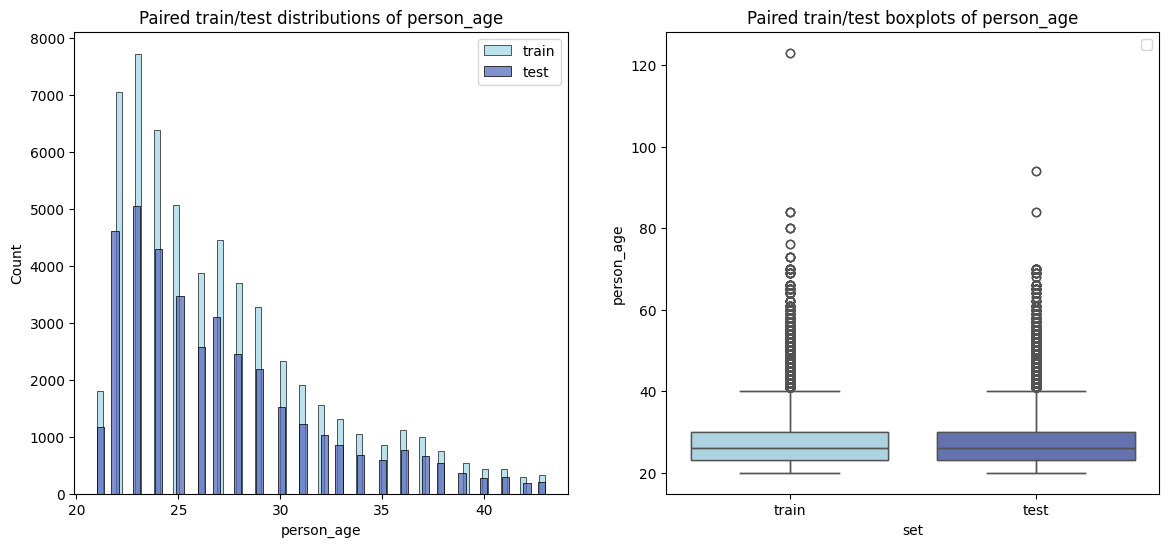

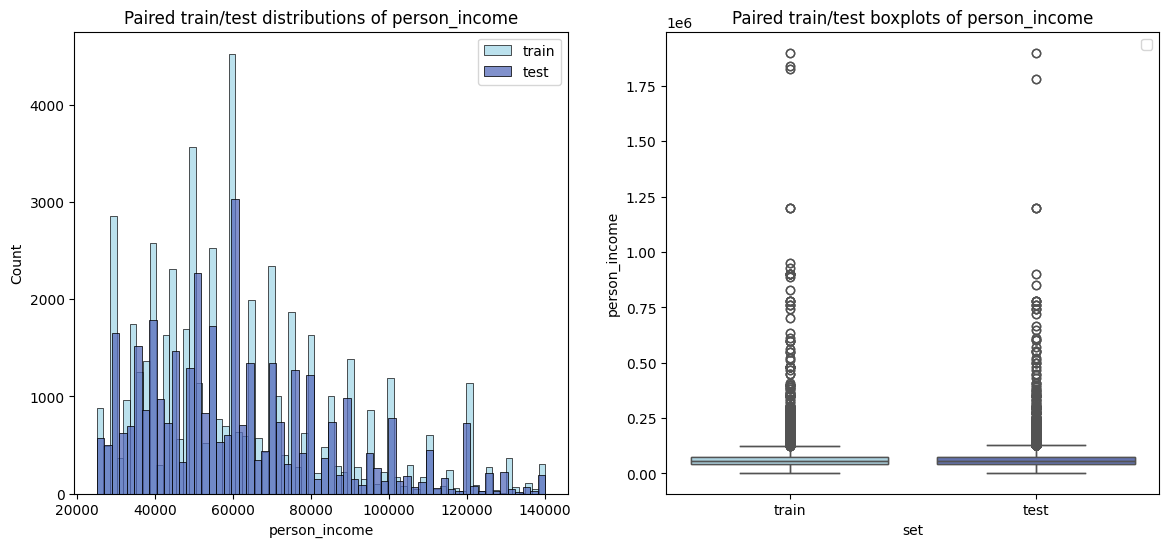

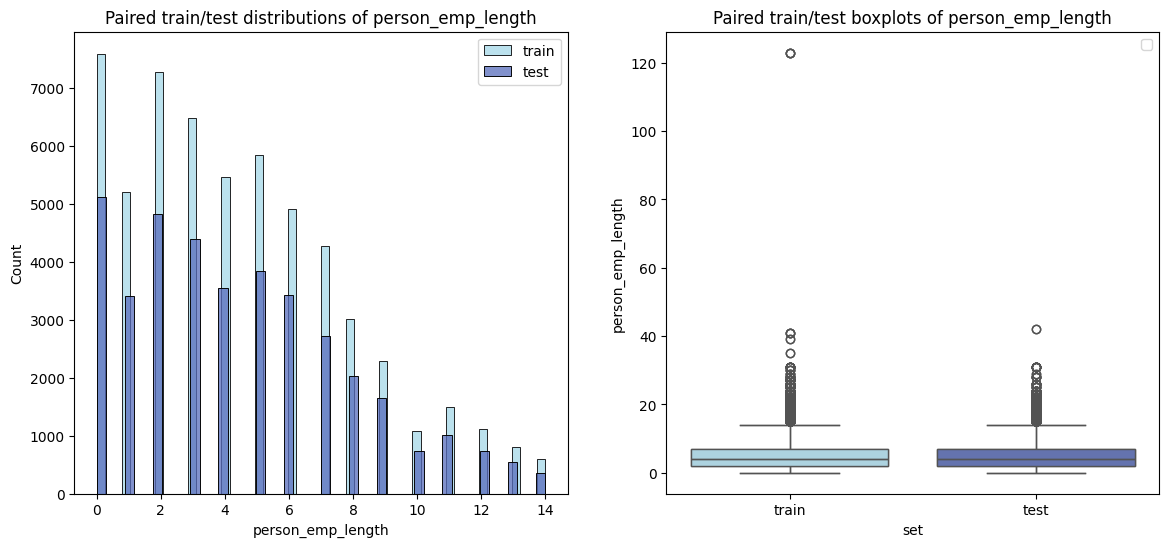

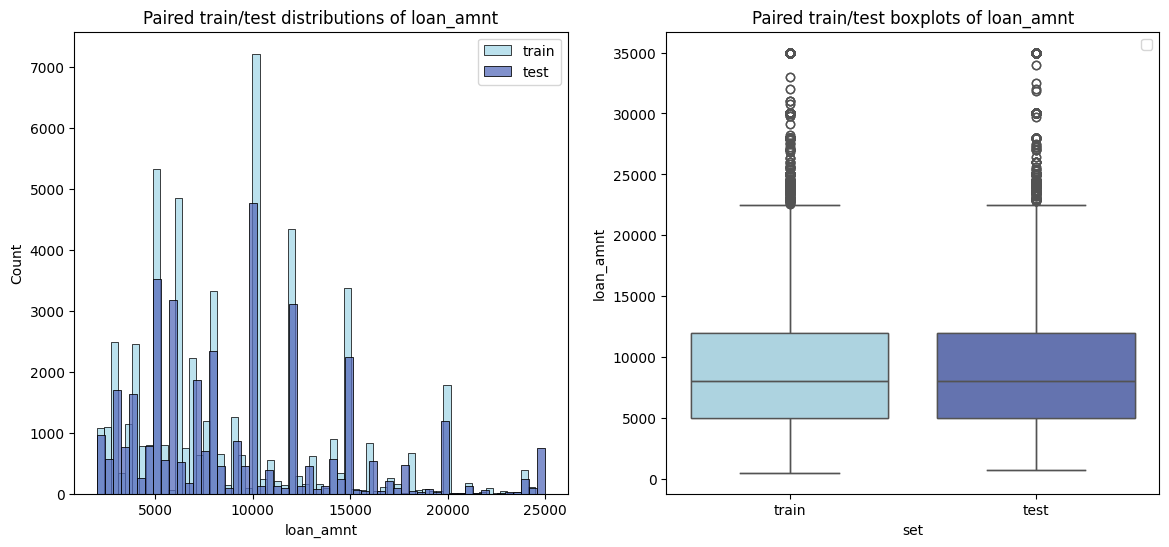

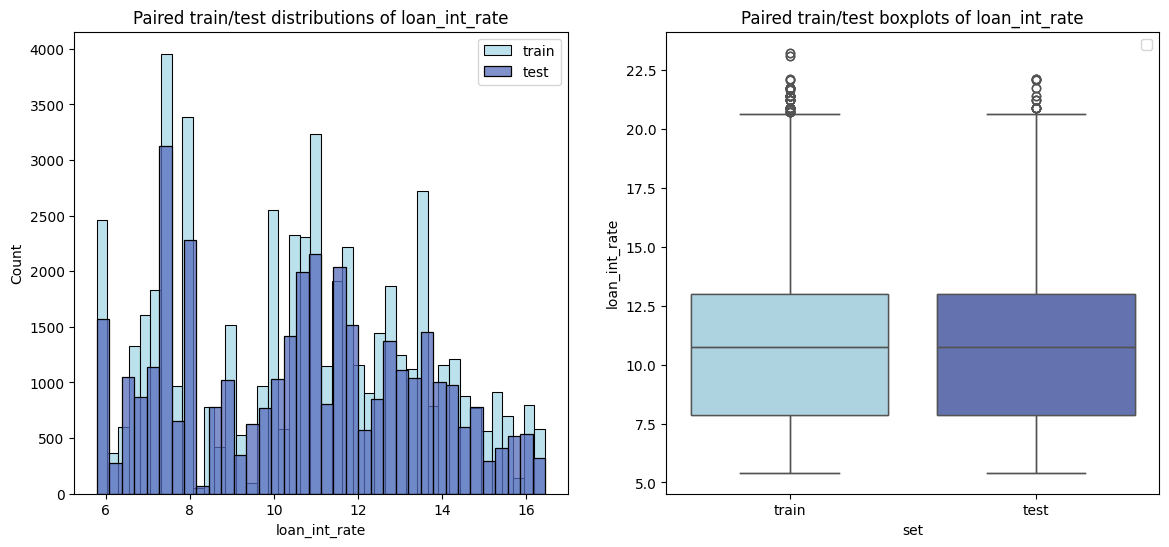

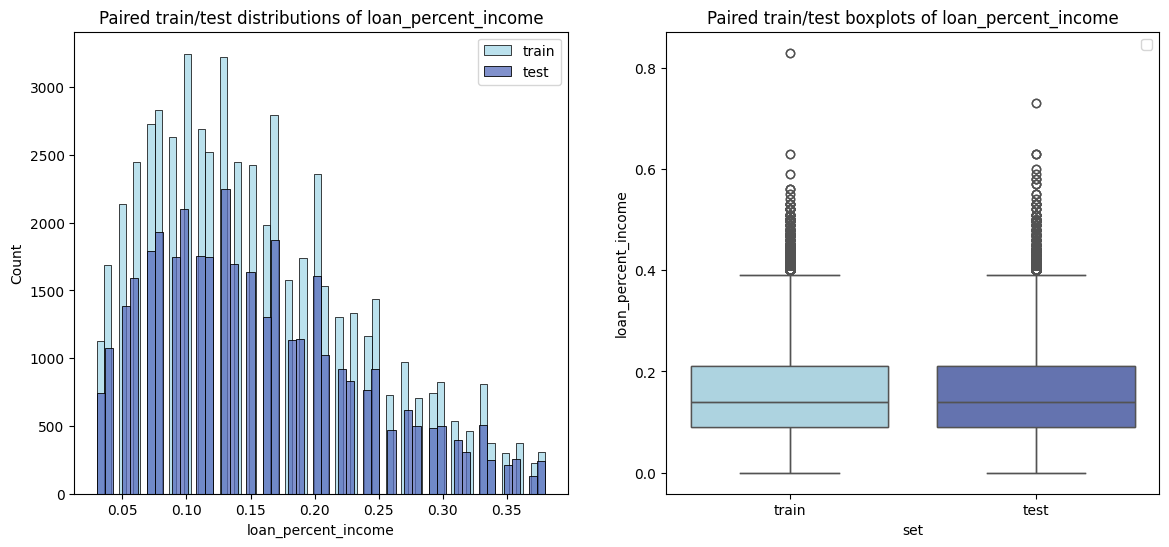

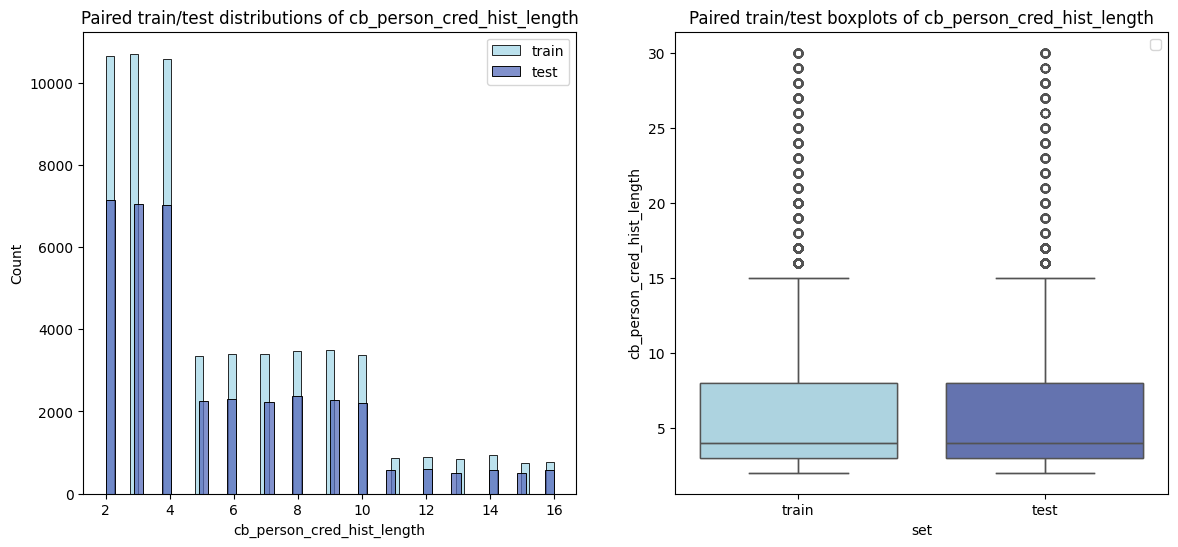

In [12]:
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


#hue parameter is just the name for the column used to separate train and test sets.
def plot_distribution_pairs(train, test, feature, hue="set", palette=["#A5D7E8", "#576CBC"]):

    #combine training and testing sets and label which set they came from
    data_df = train.copy()
    #add new column 'set' with value 'train'
    data_df['set'] = 'train'
    #filling missing values in the 'set' column with 'test' to efficiently label them
    data_df = pd.concat([data_df, test.copy()]).fillna('test')


    #creating subplots

    f, axes = plt.subplots(1, 2, figsize=(14, 6))


    for i, s in enumerate(data_df[hue].unique()):
        #select values from column 'feature' from combined data set when hue matches set s
        selection = data_df.loc[data_df[hue]==s, feature]
        #select 95% of the central data to avoid outliers
        q_025, q_975 = np.percentile(selection, [2.5, 97.5])
        selection_filtered = selection[(selection >= q_025) & (selection <= q_975)]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)

            #ax = axes[0] plots in the first subplot
            #label=s labels the data train or test
            sns.histplot(selection_filtered, color=palette[i], ax = axes[0], label=s)
            sns.boxplot(x=hue, y=feature, data=data_df, palette=palette, ax=axes[1])

    

    axes[0].set_title(f"Paired train/test distributions of {feature}")
    axes[1].set_title(f"Paired train/test boxplots of {feature}")
    axes[0].legend()
    axes[1].legend()
    plt.show()

color_list = ["#A5D7E8", "#576CBC", "#19376D", "#0B2447"]
for feature in num_cols:
    plot_distribution_pairs(train, test, feature)
